In [136]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [22]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [23]:
#1. import database/data


In [24]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """ 
           SELECT name
           FROM sqlite_master
           WHERE type= 'table'

"""

tables = pd.read_sql(sql_query,conn)
# create database for each table 
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"] = df 
    print(f"Created dataframe: df_{table_name}")

conn.close()    

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [25]:
#print table names and column names 
conn = sqlite3.connect('customer_churn.db')
for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # get column info
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())
# close conn
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [26]:
# 2. data cleaning

In [27]:
#df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [28]:
df_db_customer.info()


<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [29]:
# a. rename col - name
# b. drop columns- interests and pincode
# c. change data type - dob
# d. data standardization - gender 
# e. fix missing values - country

In [30]:
# a. rename col - namex
df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace = True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [31]:
# b. drop columns- interests and pincode

#df_db_customer.drop(df_db_customer.columns[-2:], axis = 1)
df_db_customer.drop(columns=['interests', 'pincode'], inplace = True)


In [32]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerid     21 non-null     str  
 1   customer_name  21 non-null     str  
 2   country        18 non-null     str  
 3   state          21 non-null     str  
 4   gender         21 non-null     str  
 5   dob            21 non-null     str  
dtypes: str(6)
memory usage: 1.1 KB


In [33]:
# c. change data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [34]:
# d. data standardization - gender 
# df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men':'Male', 'Women':'Female'})

In [35]:
# e. fix missing values - country

df_db_customer[df_db_customer['country'].isna()]  #tells about null values true=null



,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [36]:
# country and state - unique value pair 

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping)) 

In [37]:
df_db_customer[df_db_customer['country'].isna()] 

,customerid,customer_name,country,state,gender,dob


In [38]:
# subscription table
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [39]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [40]:
date_col = ['subscription_start_date', 'renewal_date','cancellation_date' ]

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [41]:
df_db_support

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,NaN
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,NaN
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,NaN
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [42]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [43]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [44]:
df_db_support.drop(columns=['col_1','comment'], inplace = True)

In [45]:
df_db_support['complaint_date'] = pd.to_datetime (df_db_support['complaint_date'])

df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [46]:
# 3. feature engineering and Data Analysis

In [47]:
df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34


In [48]:
# create a new column using existing col - churn flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [49]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [50]:
# first fix support column duplicates then merge 
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how ='left')
            .merge(df_db_support, on = 'customerid', how ='left'))

In [51]:
df.shape

(23, 20)

In [52]:
# but
df_db_subscription.shape

(21, 12)

In [53]:
# problem is in 7 != 9
df_db_support['customerid'].nunique()

7

In [54]:
df_db_support['customerid'].size

9

In [55]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [56]:

df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [57]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [58]:
df_db_support['customerid'].size

7

In [59]:
# merge dataframe
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how ='left')
            .merge(df_db_support, on = 'customerid', how ='left'))

In [60]:
df.shape

(21, 21)

In [61]:
df.to_csv('exported_churn_data.csv', index = False)

In [62]:
# Data Analysis - 

In [63]:
# 1. churn rate

In [64]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [65]:
churn_rate = df['churn_flag'].mean()*100
print("churn rate =", round(churn_rate,2), "%")

churn rate = 28.57 %


In [66]:
# 2. Retention rate
retention_rate = 100- churn_rate
print("Retention Rate =",round(retention_rate,2), "%")

Retention Rate = 71.43 %


In [67]:
# 3. Churn  by plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name= 'churn_rate_pct'))

print(churn_by_plan)
# max churn rate is fron basic

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [68]:
# 4 a. churn by state + sum(revenue) & count of users  
# 4 b. churn by subscription rate + sum(revenue) & count of users 

In [69]:
# 5. ARPU (average revenue per user)
arpu = df['monthly_charges'].mean()
print("ARPU =", round(arpu,2))

ARPU = 18.85


In [70]:
#6.  average customer tenure
# count of days user has used our service : cancellation date else current date
today = pd.Timestamp.today()

df['tenure_date'] =  np.where(
        df['cancellation_date'].notna(),

     (df['cancellation_date'] - df['subscription_start_date']).dt.days,     #condition is true

     (today- df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_date'].mean()
print("Avg Tenure (Days) =", round(avg_tenure),0)

Avg Tenure (Days) = 1517 0


In [71]:
#7.  Revenue at risk - revenue lost from churned users 
revenue_at_risk = df.loc[df['churn_flag']==1,'monthly_charges'].sum() 
print("revenue at risk (Rs 'k') =", revenue_at_risk)

revenue at risk (Rs 'k') = 73.94


In [72]:
#8. Escalation rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Escqalation Rate =", round(escalation_rate,2), '%')

Escqalation Rate = 19.05 %


In [75]:
#9. avg complaint per user
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg complaints per user =", round(avg_complaints,2))

Avg complaints per user = 0.43


In [77]:
#10. Correlation escalation vs churn
df['escalations'] = np.where(df['escalations'] == 'Y',1,0)     # encoding string to int type
corr_df = df[['escalations','churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between escalation vs churn  is =", round(correlation,2))

Correlation between escalation vs churn  is = 0.77


In [78]:
#11.  create a column using existing column - churn risk - 
conditions = [
         (df['churn_score'] < 50),
         (df['churn_score'] >= 50) & (df['churn_score'] < 70),
         (df['churn_score'] >= 70)
]
choices  = ['low','medium','high']

df['churn_risk'] = np.select(conditions, choices, default='unknown')

In [79]:
df[['churn_risk', 'churn_score']].head()

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88


In [144]:
# 4. Visualization using Matplotlib

In [80]:
df_visual = df.copy()

In [81]:
df_visual

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_date,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1978.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1363.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2653.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,...,India,Delhi,Female,1988-12-10,2025-03-18,0,90.0,1.0,1518.0,low
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,India,Meghalaya,Female,1976-09-21,2024-11-01,0,30.0,1.0,1142.0,high
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,...,India,Rajasthan,Male,1999-03-14,NaT,0,NaN,NaN,2373.0,low
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,...,Nepal,Kathmandu,Female,1985-07-07,NaT,0,NaN,NaN,1119.0,low
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,...,Nepal,Kathmandu,Male,1993-10-29,NaT,0,NaN,NaN,1594.0,low


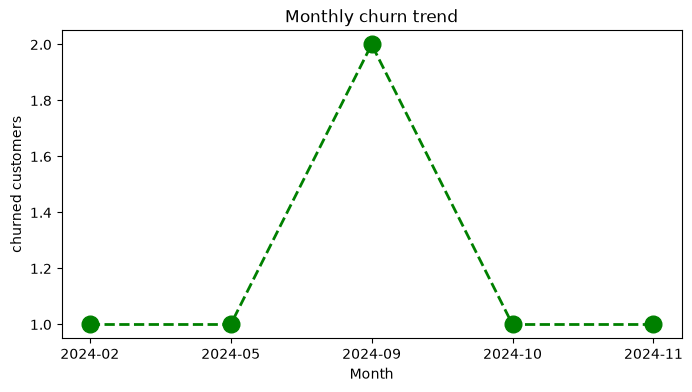

In [82]:
#4.1 Mounthly churn Trend (Time series KPI)

df_visual['cancellation_month']= df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,4))
plt.plot(churn_trend.index.astype(str),churn_trend.values,color='green', marker='o', linestyle='dashed',linewidth=2, markersize=12)

plt.title('Monthly churn trend')
plt.xlabel('Month')
plt.ylabel('churned customers')
plt.show()

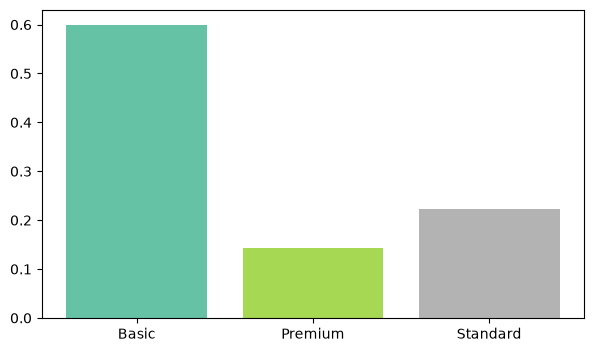

In [83]:
#4.2 Churn by plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

#colours = ['yellow','Red','blue']
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors )
plt.show()

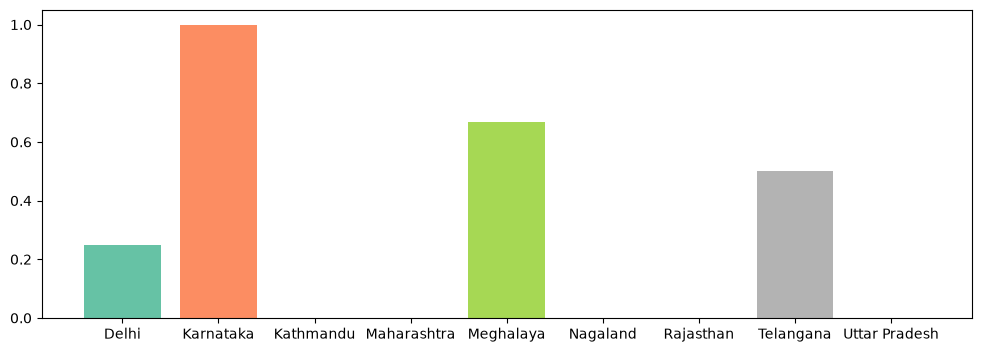

In [84]:
#4.3 Churn by states 
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

#colours = ['yellow','Red','blue']
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors )
plt.show()

In [85]:
# Visualization using Seaborn


In [86]:
# encoding - convert string to numeric so that we can find corr between features 
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_date', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [87]:
#df_encoded = 
df_visual[['plan_type', 'contract_type','churn_score','churn_flag',  'escalations','churn_risk']].head()


,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,0,low
1,Premium,Annual,91,1,1,high
2,Basic,Monthly,34,0,0,low
3,Premium,Annual,8,0,0,low
4,Standard,Monthly,88,1,1,high


In [95]:
# incorrect method of encoding as numbers are not assigned based on priotiry
df_encoded = df_visual[['plan_type', 'contract_type','churn_score','churn_flag',  'escalations','churn_risk']].head()

categorial_cols = ['plan_type', 'contract_type', 'churn_risk']
for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes
    

In [91]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,2,0,12,0,0,1
1,1,0,91,1,1,0
2,0,1,34,0,0,1
3,1,0,8,0,0,1
4,2,1,88,1,1,0


<Axes: >

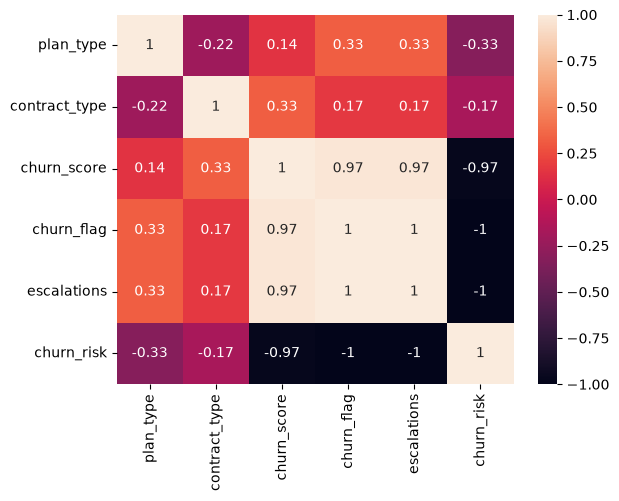

In [96]:
# heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

In [109]:
# correct method of encoding - based on priotiry
df_encoded = df_visual[['plan_type', 'contract_type','churn_score','churn_flag','churn_risk', 'escalations']].head()

order_mappings = {
    'plan_type' : ['Basic','Standard','Premium'], 
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk' : ['low','medium','high']
    }
for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories = order, ordered=True ).codes

In [110]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


In [102]:
df_visual[['plan_type', 'contract_type','churn_score','churn_flag',  'escalations','churn_risk']].head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,0,low
1,Premium,Annual,91,1,1,high
2,Basic,Monthly,34,0,0,low
3,Premium,Annual,8,0,0,low
4,Standard,Monthly,88,1,1,high


<Axes: >

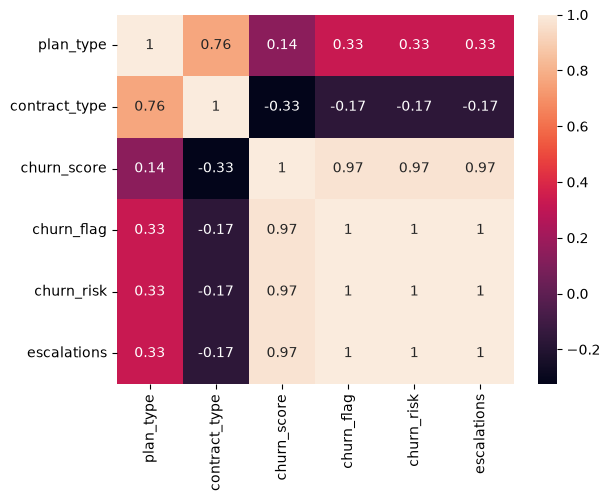

In [111]:
# heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

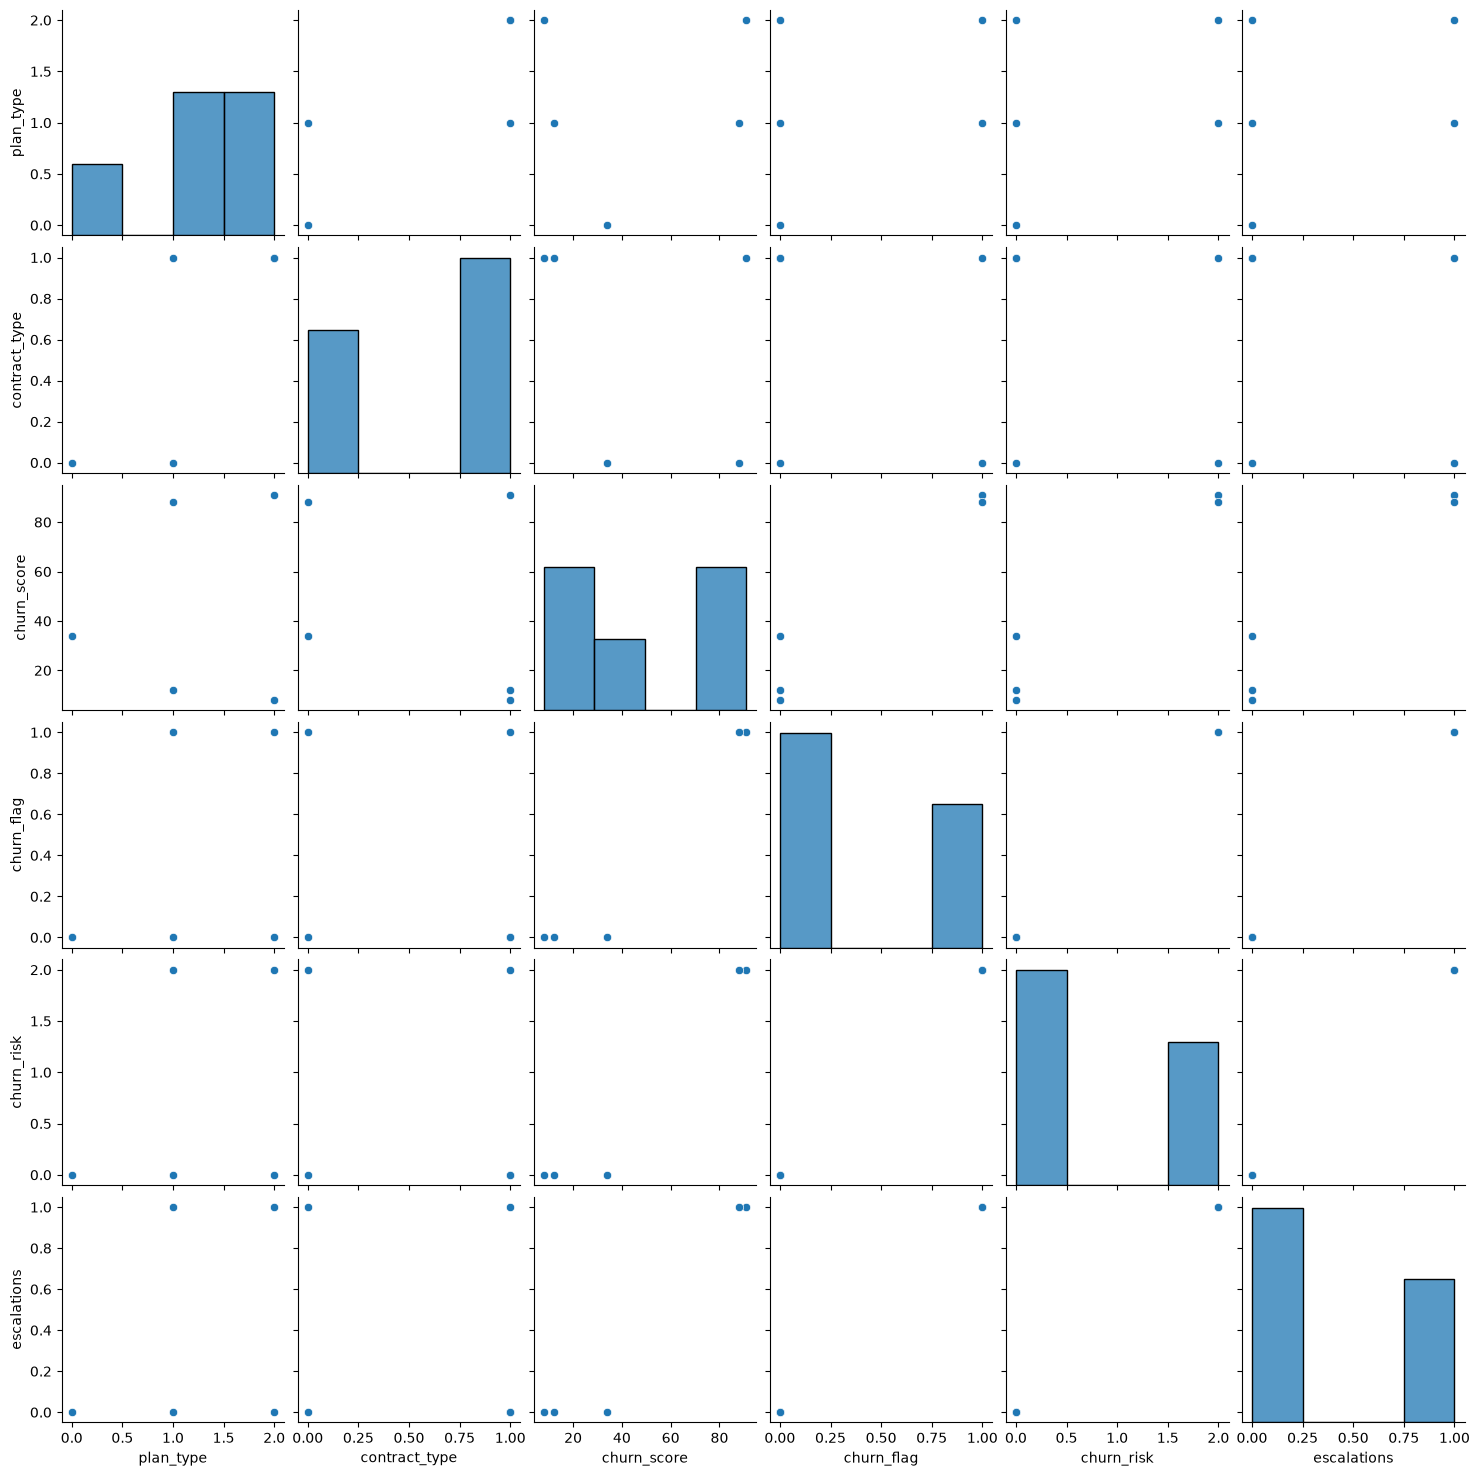

In [113]:
# Pairplot relationship in a dataset
sns.pairplot(df_encoded)

In [115]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_date', 'churn_risk', 'cancellation_month'],
      dtype='str')

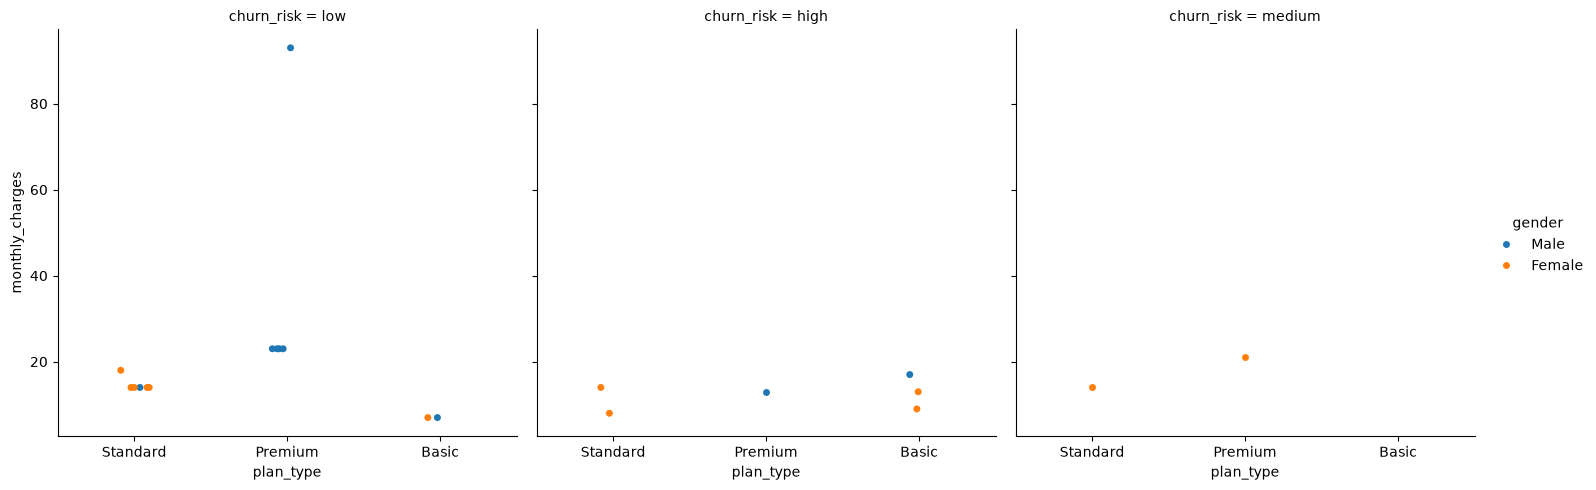

In [117]:
# Catplt/ facegrid plot - multi dimension comparision
sns.catplot(data=df_visual,
           x='plan_type',
           y='monthly_charges',
           hue='gender',
           col='churn_risk',)

In [118]:
# Pivot table

In [120]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc = 'mean',
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [121]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid','churn_flag'],
    aggfunc = { 'monthly_charges' : 'sum',
                'customerid': 'nunique',
                'churn_flag' : 'mean'
    }
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


In [122]:
# working with sql with python (pandas)

In [132]:
# create database   in sql
conn = sqlite3.connect('test_db.sqlite')

#tabel details
conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)")
#commit and save
conn.commit()

OperationalError: table users already exists

In [126]:
#insert data

#write sql query to inserts records in sql table
cursor = conn.cursor()
cursor.execute(
    """
       INSERT INTO users values 
          ('Madhav', 'India', 5000),
          ('Rishabh','Germany', 9000),
          ('Vishaka','India', 35100)
       
    """  
) 
#commit and save
conn.commit()

In [133]:
# check inserted data in table
conn = sqlite3.connect('test_db.sqlite')
query = """ SELECT * FROM users  """
df_results = pd.read_sql(query, conn)

df_results.head()

,first_name,country,budger
0,Madhav,India,5000
1,Rishabh,Germany,9000
2,Vishaka,India,35100


In [134]:
# aggregation
query = """
         SELECT country, SUM(budger) as Total_budget
         FROM users 
         GROUP BY country
"""
df_agg = pd.read_sql(query, conn)
df_agg

,country,Total_budget
0,Germany,9000
1,India,40100


In [135]:
conn.close()